# Mirror WGF on a constrained scale

### Setup

We simulate data from a two-component Gaussian mixture $P_0$ with **shared mean** but **different variances**:

$$P_0 = w\,\mathcal{N}(\mu,\,\sigma_\mathrm{low}^2) + (1-w)\,\mathcal{N}(\mu,\,\sigma_\mathrm{high}^2).$$

Because both components share $\mu$, the marginal variance is $w\sigma_\mathrm{low}^2 + (1-w)\sigma_\mathrm{high}^2$. We fit a Gaussian scale model in PyMC with **fixed mean** and a `HalfNormal` scale parameter, then sample its predictively oriented posterior via `sample_pro`.

Positive parameters use the **mirror-mapped WGF** step (Gu & Kim, [arXiv:2505.02621](https://arxiv.org/abs/2505.02621)): particles evolve in dual `value_vars` coordinates while drift and noise follow the primal SDE with $\sigma(y)=\exp(-\tfrac12\log\mathrm{jac\_det})$. The ArviZ `posterior` group stores primal $\sigma$, not `sigma_log__`.

We use the tuning-free **FUSE** schedule (`step_size=None`) as in `bimodal_gaussian.ipynb`. After a warmup window (`tune`), every retained step is treated as a draw from the (approximate) stationary particle measure.


In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

import pymc_prop as pro

az.style.use("arviz-variat")


In [2]:
N = 400
MU = 0.0
SIGMA_LOW = 0.5
SIGMA_HIGH = 2.0
WEIGHT = 0.5
SEED = 2026

marginal_var = WEIGHT * SIGMA_LOW**2 + (1 - WEIGHT) * SIGMA_HIGH**2
marginal_std = np.sqrt(marginal_var)

rng = np.random.default_rng(SEED)
components = rng.choice(2, size=N, p=[WEIGHT, 1 - WEIGHT])
scales = np.where(components == 0, SIGMA_LOW, SIGMA_HIGH)
y = rng.normal(MU, scales)

xlim = (y.min() - 1.0, y.max() + 1.0)


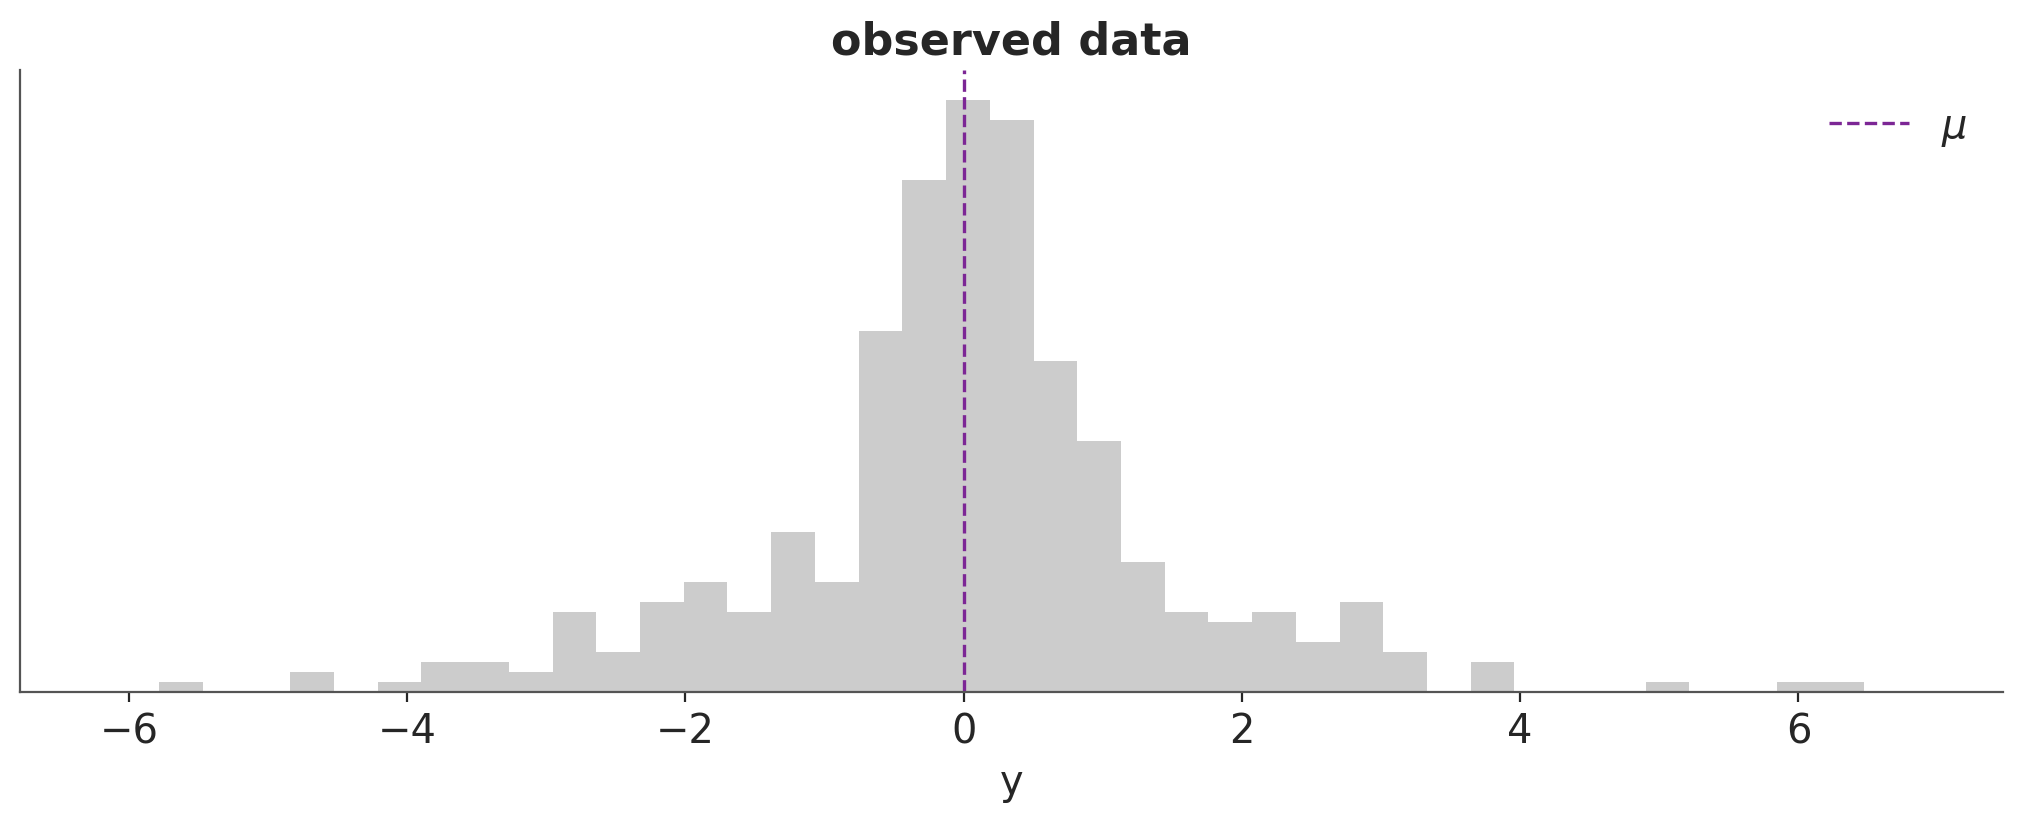

In [3]:
_, ax = plt.subplots(figsize=(10, 4))
ax.hist(y, bins="auto", color="0.8", edgecolor=None)
ax.axvline(MU, color="C3", ls="--", lw=1.2, label=r"$\mu$")
ax.set(title="observed data", xlabel="y", xlim=xlim, yticks=[])
ax.legend();


## PyMC model (constrained scale)

We fix $\mu$ at the simulation value and place $\sigma \sim \mathrm{HalfNormal}(2)$, then $y_i \mid \sigma \sim \mathcal{N}(\mu, \sigma^2)$, so the demo focuses on the constrained scale. The likelihood is still misspecified: a single Gaussian cannot match $P_0$, but a scale mixture of Gaussians can.


In [4]:
with pm.Model() as model:
    sigma = pm.HalfNormal("sigma", sigma=2.0)
    pm.Normal("y", mu=MU, sigma=sigma, observed=y)


### Run the sampler

Constrained parameters are automatically detected; the flow uses a mirror-mapped geometry based on the default PyMC [transformations](https://www.pymc.io/projects/docs/en/stable/api/distributions/transforms.html).


In [5]:
dt = pro.sample_pro(
    model=model,
    n_particles=150,
    n_steps=2000,
    tune=500,
    random_seed=SEED,
)


In [6]:
# mirror packing: posterior under free-RV name; values stay positive
assert "sigma" in dt.posterior
assert "sigma_log__" not in dt.posterior

sigma_trace = dt.posterior["sigma"]
print("min sigma over all retained steps:", float(sigma_trace.min()))
print("retained sigma mean:", float(sigma_trace.mean()))
print("marginal std of P_0:", marginal_std)


min sigma over all retained steps: 0.016565722418409
retained sigma mean: 1.2701081905573373
marginal std of P_0: 1.4577379737113252


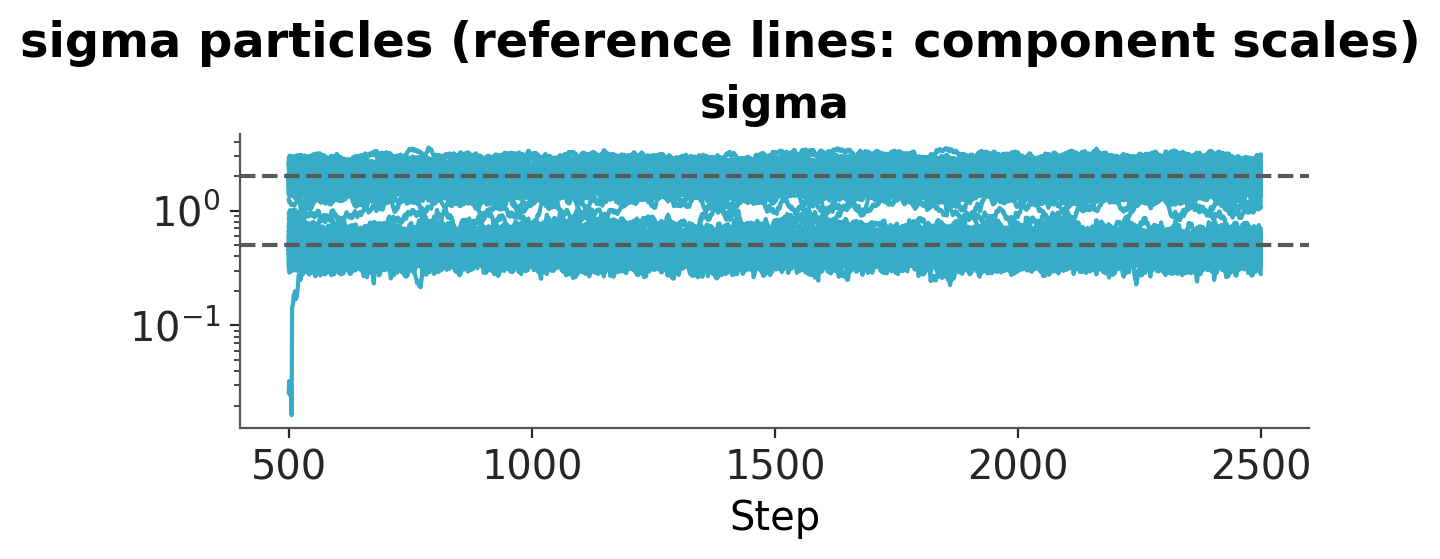

In [7]:
# plot particle trajectories (log scale: σ stays > 0 under the mirror map)
pc = az.plot_trace(
    dt,
    var_names=["sigma"],
    aes={"color": False, "overlay": ["chain"]},
    visuals={"trace": {"color": "C0", "xname": "step"}},
)
pc = az.add_lines(pc, values=[SIGMA_LOW], orientation="horizontal")
pc = az.add_lines(pc, values=[SIGMA_HIGH], orientation="horizontal")
pc.facet_map("set_yscale", scale="log")
pc.add_title("sigma particles (reference lines: component scales)")


Mirror mapping keeps every particle on the constrained axis: $\sigma>0$ throughout (see the log-scaled trajectories above and `min sigma` printout).


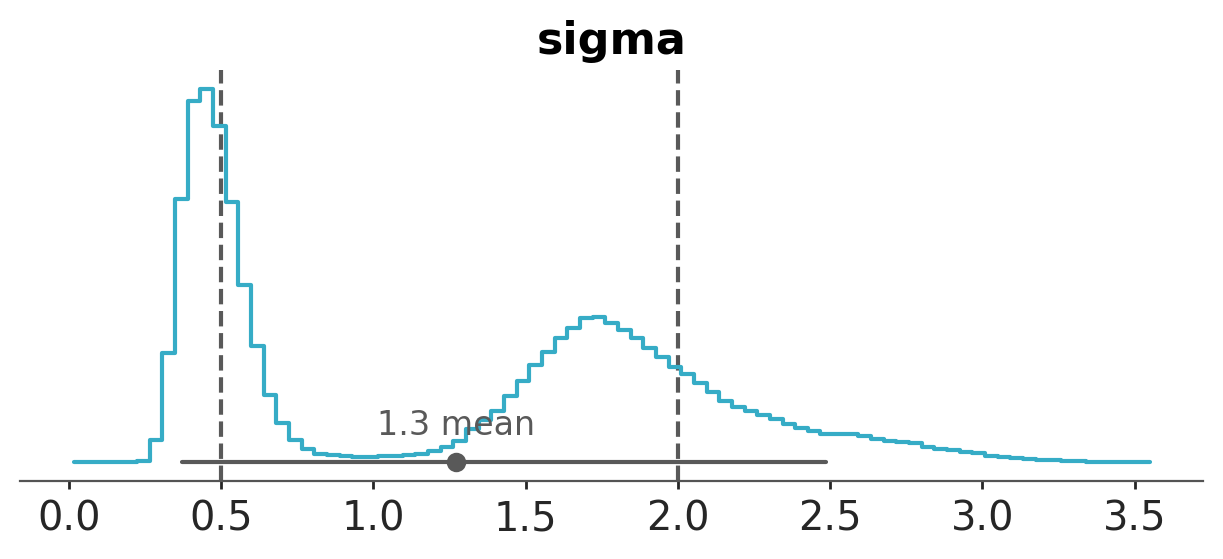

In [8]:
# plot posterior histogram (pooled draw × chain after tune)
pc = az.plot_dist(
    dt,
    var_names=["sigma"],
    kind="hist",
)
pc = az.add_lines(pc, values=[SIGMA_LOW], orientation="vertical")
pc = az.add_lines(pc, values=[SIGMA_HIGH], orientation="vertical")


## Posterior predictive check

Because the PrO cloud puts mass on both small and large scales, the induced predictive is a scale mixture of Gaussians and can track the heavy-tailed shape of $P_0$ more closely than any single-$\sigma$ Gaussian. A Bayesian posterior for the same misspecified model would typically concentrate on one compromise scale and show poorer predictive calibration; we omit that comparison here, but it is a useful check if you are new to predictively oriented posteriors.


In [9]:
ppc_dt = pro.sample_posterior_predictive_pro(
    dt,
    model=model,
    random_seed=SEED,
)


Sampling: [y]


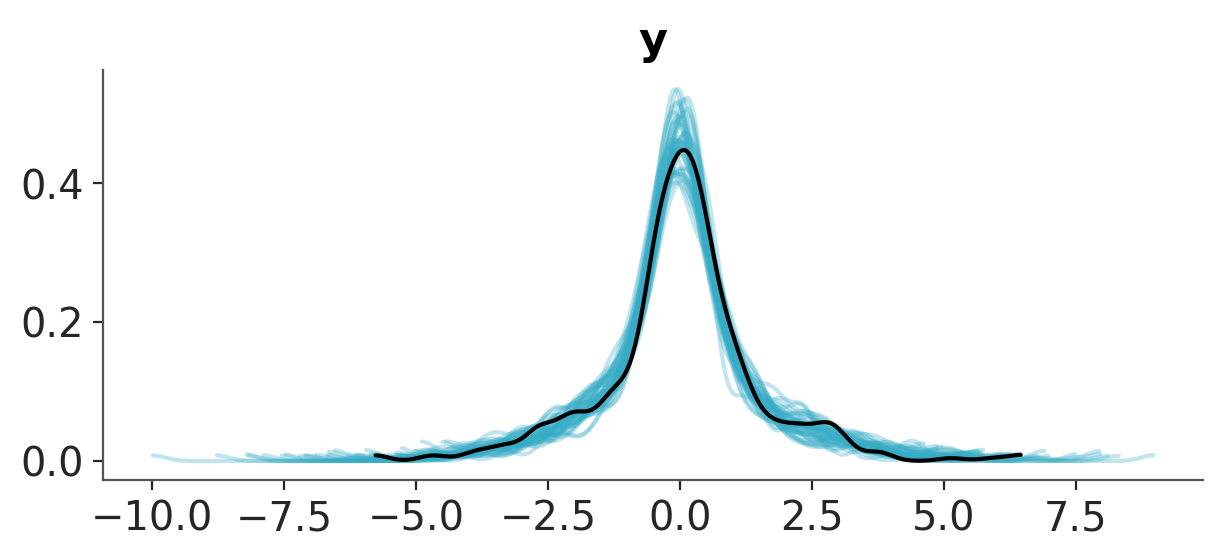

In [10]:
az.plot_ppc_dist(ppc_dt, num_samples=40);
